## Plot losses and grad norms

/tmp/ipykernel_927820/526522514.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  log_history = torch.load(os.path.join(STORAGE_DIR, exp_dir, "training_metrics_hf.pth"))


[9.829416275024414, 59.060813903808594, 19.35935401916504, 10.976334571838379, 17.081134796142578, 11.347271919250488, 10.513540267944336, 11.962831497192383, 14.313082695007324, 8.869327545166016, 14.845376968383789, 10.394296646118164, 13.545827865600586, 12.789451599121094, 7.96544075012207, 9.003067016601562, 13.843992233276367, 10.60777473449707, 9.182912826538086, 8.63326644897461, 9.24307918548584, 6.997625350952148, 6.967724800109863, 4.409225940704346, 9.98534870147705, 6.993706703186035, 6.008040428161621, 7.538815021514893, 7.075657844543457, 8.264111518859863, 7.068687915802002, 5.958841800689697, 8.87771224975586, 6.092546463012695, 7.727424144744873, 5.295422077178955, 5.4219441413879395, 4.668654918670654, 4.556450366973877, 3.841435194015503, 6.461939334869385, 6.056857585906982, 3.965254306793213, 5.247541427612305, 5.61179780960083, 5.791757583618164, 5.6330461502075195, 14.905137062072754, 9.81560230255127, 6.364221572875977, 35.9285774230957, 6.606295585632324, 6.88

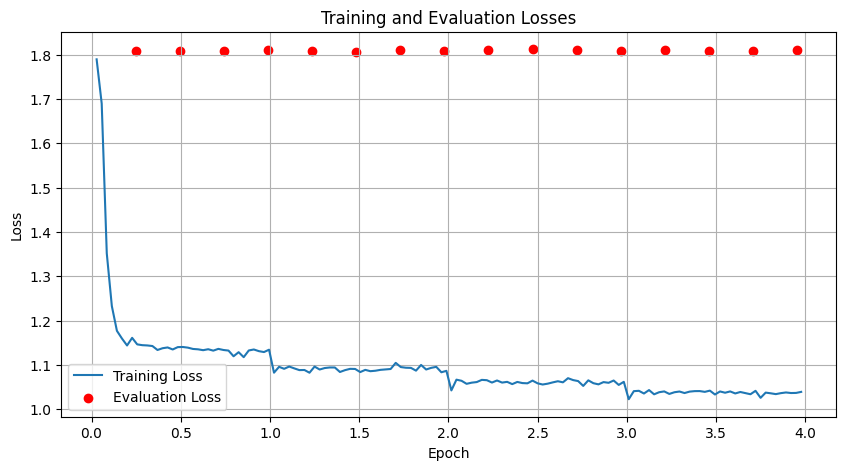

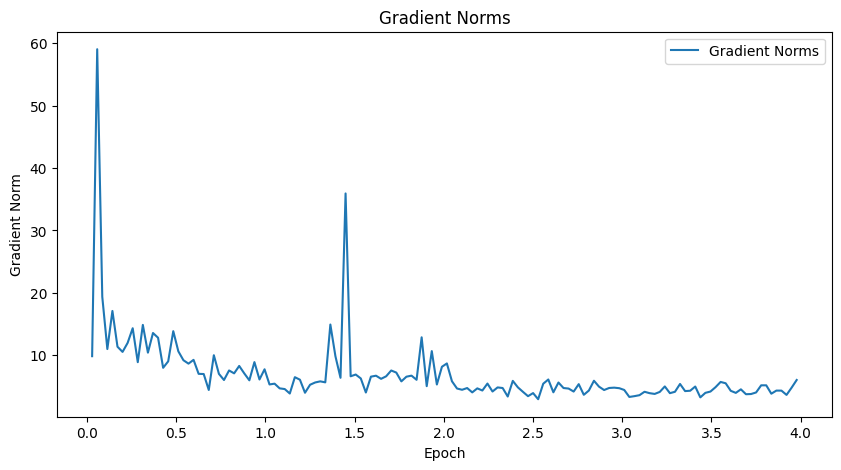

<Figure size 640x480 with 0 Axes>

In [1]:
import torch
import matplotlib.pyplot as plt

import os
STORAGE_DIR = os.getenv("STORAGE_DIR", "/media/discoexterno/leon")

def plot_training_metrics():

    # Load saved log history from the HF Trainer.
    # This file should contain a list of dictionaries with logged metrics.
    exp_dir = "ms_marco_passage/results/IR_unsloth_qwen0.5B_5negs_rslora_25k_4epochs"
    log_history = torch.load(os.path.join(STORAGE_DIR, exp_dir, "training_metrics_hf.pth"))

    gradient_accumulation_steps = 4

    # Initialize lists to store metrics
    train_losses = []
    eval_losses = []
    grad_norms = []
    train_epochs = []
    eval_epochs = []

    # Iterate over each log entry and extract the metrics.
    for entry in log_history:
        # Check if a training loss is logged.
        if "loss" in entry:
            train_losses.append(entry["loss"] / gradient_accumulation_steps)
            train_epochs.append(entry["epoch"])
        # Check if an evaluation loss is logged.
        if "eval_loss" in entry:
            eval_losses.append(entry["eval_loss"])
            eval_epochs.append(entry["epoch"])
        # Check if a gradient norm is logged.
        if "grad_norm" in entry:
            grad_norms.append(entry["grad_norm"])

    print(grad_norms)
        
    # Plot training losses and evaluation losses in one plot.
    plt.figure(figsize=(10, 5))
    plt.plot(train_epochs, train_losses, label="Training Loss")
    # plot eval loss with dots scatter
    plt.scatter(eval_epochs, eval_losses, label="Evaluation Loss", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Evaluation Losses")
    plt.legend()
    plt.grid()
    plt.savefig(os.path.join(STORAGE_DIR, exp_dir, "training_eval_losses.png"))

    # Plot gradient norms in a separate plot.
    plt.figure(figsize=(10, 5))
    plt.plot(train_epochs, grad_norms, label="Gradient Norms")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.title("Gradient Norms")
    plt.legend()
    plt.show()
    plt.savefig(os.path.join(STORAGE_DIR, exp_dir, "grad_norms.png"))


if __name__ == "__main__":
    plot_training_metrics()

## Analyse tokenized sequence lengths

In [9]:
# add ..utils.train_utils to the sys.path
import sys
sys.path.append("..")
print("Executable", sys.executable)

from unsloth import FastLanguageModel
from utils.train_utils import (
    get_msmarco_queries,
    get_msmarco_passages,
    get_msmarco_hard_negatives,
    tokenize_train_ds_msmarco,
    tokenize_test_ds_msmarco
)

qid_to_query = get_msmarco_queries()
pid_to_passage = get_msmarco_passages()
num_negs = 5
print("Training on MS MARCO dataset...")
negs_ds = get_msmarco_hard_negatives(num_negs, reload=True)
negs_ds = negs_ds.select(range(100_000))

# split negs_ds into train and eval sets with a 90/10 ratio
split = negs_ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
test_ds = split["test"]

model, tokenizer = FastLanguageModel.from_pretrained(
    # Can select any from the below:
    # "unsloth/Qwen2.5-0.5B", "unsloth/Qwen2.5-1.5B", "unsloth/Qwen2.5-3B"
    # "unsloth/Qwen2.5-14B",  "unsloth/Qwen2.5-32B",  "unsloth/Qwen2.5-72B",
    # And also all Instruct versions and Math. Coding verisons!
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = 512,
    dtype = "bf16",
    load_in_4bit = False,
    # device_map="cuda:1",
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

# Apply tokenization to the dataset
train_ds = tokenize_train_ds_msmarco(tokenizer, train_ds, qid_to_query, pid_to_passage, num_negs, reuse=False)
test_ds = tokenize_test_ds_msmarco(tokenizer, test_ds, qid_to_query, pid_to_passage, num_negs, reuse=False)

Executable /home/leon/tesis/Environments/IR_env/bin/python
Loading MS MARCO queries...Done
Loading MS MARCO passages...Done
Training on MS MARCO dataset...
Loading hard negatives...Done
==((====))==  Unsloth 2025.2.9: Fast Llama patching. Transformers: 4.48.3.
   \\   /|    GPU: NVIDIA RTX A5000. Max memory: 23.679 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu124. CUDA: 8.6. CUDA Toolkit: 12.4. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post1. FA2 = True]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Tokenizing train dataset...Done
Tokenizing test dataset...Done


100%|██████████| 90000/90000 [00:00<00:00, 185251.78it/s]


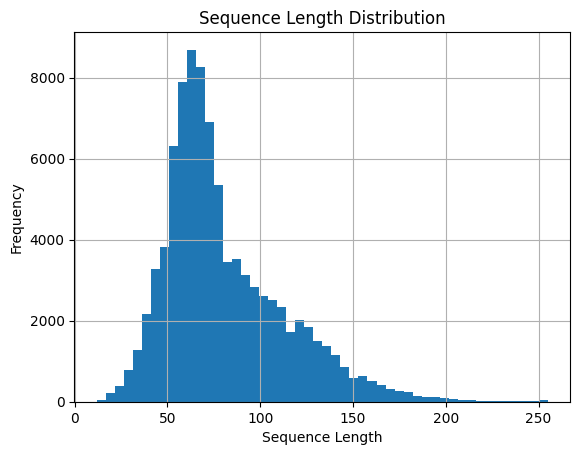

In [10]:
import matplotlib.pyplot as plt
from tqdm import tqdm

seq_lengths = []
# Get the length of each sequence
for example in tqdm(train_ds["doc_input_ids"]):
    eos_position = example.index(tokenizer.eos_token_id)
    seq_lengths.append(eos_position)

plt.hist(seq_lengths, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Sequence Length Distribution")
plt.grid()
plt.show()

# SOLUTION: max seq len of 128 for passages should be sufficient for Llama!

100%|██████████| 90000/90000 [00:00<00:00, 237219.48it/s]


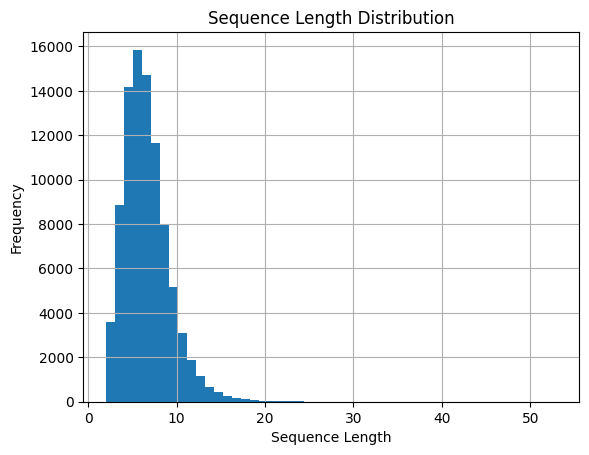

In [8]:
import matplotlib.pyplot as plt
from tqdm import tqdm

seq_lengths = []
# Get the length of each sequence
for example in tqdm(train_ds["query_input_ids"]):
    eos_position = example.index(tokenizer.eos_token_id)
    seq_lengths.append(eos_position)

plt.hist(seq_lengths, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Sequence Length Distribution")
plt.grid()
plt.show()

# SOLUTION: max seq len of 20 for passages should be sufficient for Llama!